# Phase 5: Model Deployment and Prediction

This notebook loads the final saved restaurant-location feasibility pipeline, validates its metadata, interprets the model using `dataset_final_entropy.csv`, and prepares reusable single-location and batch prediction functions.

The deployment dataset contains the entropy-based criteria `Demand`, `Accessibility`, `Competition`, and `Population`, together with location information, feasibility score, cluster, and feasibility label.

The notebook assumes the project structure contains `backend/models`, `data/processed`, and `outputs/model_results`.


In [1]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================
# These libraries are used for:
#
# - File and folder handling
# - Loading the saved model package
# - Data validation and manipulation
# - Model interpretation
# - Prediction and result visualisation

from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", None)

print("Required libraries imported successfully.")


Required libraries imported successfully.


In [2]:
# ============================================================
# 2. LOCATE THE PROJECT ROOT DIRECTORY
# ============================================================
# This avoids path errors when the notebook is opened from:
#
# - The notebooks folder
# - The project root folder
# - Another working directory
#
# The code searches the current folder and its parent folders
# for the expected project structure.

def find_project_root(start_path=None):
    """Find the restaurant feasibility project root folder."""

    current_path = Path(
        start_path or Path.cwd()
    ).resolve()

    candidate_paths = [
        current_path,
        *current_path.parents
    ]

    for candidate in candidate_paths:
        if (
            (candidate / "backend").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    # Standard fallback when this notebook is stored in notebooks/.
    return current_path.parent


PROJECT_ROOT = find_project_root()

MODEL_PATH = (
    PROJECT_ROOT
    / "backend"
    / "models"
    / "restaurant_feasibility_pipeline.joblib"
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_final_entropy.csv"
)

OUTPUT_DIRECTORY = (
    PROJECT_ROOT
    / "outputs"
    / "model_results"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Model path:", MODEL_PATH)
print("Dataset path:", DATA_PATH)
print("Output directory:", OUTPUT_DIRECTORY)


Project root: C:\Users\mausa\Desktop\grouping_approach\minor_prj
Model path: C:\Users\mausa\Desktop\grouping_approach\minor_prj\backend\models\restaurant_feasibility_pipeline.joblib
Dataset path: C:\Users\mausa\Desktop\grouping_approach\minor_prj\data\processed\dataset_final_entropy.csv
Output directory: C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results


In [3]:
# ============================================================
# 3. LOAD THE SAVED MODEL PACKAGE
# ============================================================
# The saved package must contain:
#
# pipeline:
# The complete preprocessing and tuned Logistic Regression
# pipeline saved at the end of Phase 4.
#
# metadata:
# Feature lists, label mapping, model name, evaluation metrics,
# and other information required during deployment.

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "Saved model was not found.\n"
        f"Expected path: {MODEL_PATH}\n\n"
        "Run the final model-saving cell from Phase 4 first."
    )

model_package = joblib.load(
    MODEL_PATH
)

if not isinstance(model_package, dict):
    raise TypeError(
        "The saved object must be a dictionary containing "
        "'pipeline' and 'metadata'."
    )

required_package_keys = {
    "pipeline",
    "metadata"
}

missing_package_keys = (
    required_package_keys
    - set(model_package.keys())
)

if missing_package_keys:
    raise KeyError(
        "The model package is missing these keys: "
        f"{sorted(missing_package_keys)}"
    )

loaded_pipeline = model_package["pipeline"]
loaded_metadata = model_package["metadata"]

print("Final model package loaded successfully.")
print(
    "Model:",
    loaded_metadata.get(
        "model_name",
        type(loaded_pipeline).__name__
    )
)


Final model package loaded successfully.
Model: Logistic Regression


In [4]:
# ============================================================
# 4. VALIDATE AND EXTRACT MODEL METADATA
# ============================================================
# Deployment must use exactly the same feature names and order
# that were used while training the saved pipeline.

required_metadata_keys = {
    "model_features",
    "numeric_features",
    "categorical_features",
    "label_mapping"
}

missing_metadata_keys = (
    required_metadata_keys
    - set(loaded_metadata.keys())
)

if missing_metadata_keys:
    raise KeyError(
        "The saved metadata is missing these required keys: "
        f"{sorted(missing_metadata_keys)}"
    )

MODEL_FEATURES = list(
    loaded_metadata["model_features"]
)

NUMERIC_FEATURES = list(
    loaded_metadata["numeric_features"]
)

CATEGORICAL_FEATURES = list(
    loaded_metadata["categorical_features"]
)

LABEL_MAPPING = {
    int(class_value): str(class_name)
    for class_value, class_name
    in loaded_metadata["label_mapping"].items()
}

if set(MODEL_FEATURES) != set(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES
):
    raise ValueError(
        "The model feature list does not match the combined "
        "numeric and categorical feature lists."
    )

print("Metadata validated successfully.")
print("Number of model features:", len(MODEL_FEATURES))
print("Number of numeric features:", len(NUMERIC_FEATURES))
print("Number of categorical features:", len(CATEGORICAL_FEATURES))
print("Label mapping:", LABEL_MAPPING)


Metadata validated successfully.
Number of model features: 5
Number of numeric features: 4
Number of categorical features: 1
Label mapping: {0: 'Low', 1: 'Moderate', 2: 'High'}


In [5]:
# ============================================================
# 5. DISPLAY THE REQUIRED MODEL INPUT FEATURES
# ============================================================
# A deployment application must generate all these raw values
# before sending a location to the saved model.

feature_type_rows = []

for feature in MODEL_FEATURES:
    feature_type_rows.append({
        "Feature": feature,
        "Feature Type": (
            "Numeric"
            if feature in NUMERIC_FEATURES
            else "Categorical"
        )
    })

required_features_df = pd.DataFrame(
    feature_type_rows
)

display(required_features_df)


,Feature,Feature Type
0,Demand,Numeric
1,Accessibility,Numeric
2,Competition,Numeric
3,Population,Numeric
4,search_area,Categorical


In [6]:
# ============================================================
# 6. DISPLAY SAVED MODEL PERFORMANCE INFORMATION
# ============================================================
# .get() is used so the notebook remains compatible even when
# an optional metric was not included in the saved metadata.

metric_key_mapping = {
    "Model": "model_name",
    "Cross-validation Macro F1": "cross_validation_macro_f1",
    "Test Accuracy": "test_accuracy",
    "Test Macro Precision": "test_macro_precision",
    "Test Macro Recall": "test_macro_recall",
    "Test Macro F1": "test_macro_f1",
    "Test Weighted F1": "test_weighted_f1",
    "Test Log Loss": "test_log_loss"
}

model_summary = {
    display_name: loaded_metadata.get(metadata_key, np.nan)
    for display_name, metadata_key
    in metric_key_mapping.items()
}

model_summary_df = pd.DataFrame(
    [model_summary]
)

display(model_summary_df.round(4))


,Model,Cross-validation Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Test Log Loss
0,Logistic Regression,0.995,0.994,0.9934,0.9951,0.9942,NaN,NaN


In [7]:
# ============================================================
# 7. DISPLAY THE FINAL PIPELINE STRUCTURE
# ============================================================
# This confirms that preprocessing and the classifier are stored
# together inside one deployable pipeline.

print(loaded_pipeline)

if hasattr(loaded_pipeline, "named_steps"):
    print("\nPipeline steps:")
    for step_name, step_object in loaded_pipeline.named_steps.items():
        print(
            f"- {step_name}: "
            f"{type(step_object).__name__}"
        )


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Demand', 'Accessibility',
                                                   'Competition',
                                                   'Population']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                     

In [8]:
# ============================================================
# 8. LOAD DATASET_FINAL_ENTROPY FOR MODEL INTERPRETATION
# ============================================================
# The saved model can make predictions without loading the
# dataset again.
#
# dataset_final_entropy.csv is loaded here only for:
#
# - Checking whether the deployment features exist
# - Permutation feature importance
# - Deployment verification using an existing row
# - Creating realistic demonstration inputs
# - Checking valid search-area categories

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)

    print("dataset_final_entropy loaded successfully.")
    print("Dataset path:", DATA_PATH)
    print("Dataset shape:", df.shape)
    print("\nDataset columns:")
    print(df.columns.tolist())
else:
    df = None

    print(
        "dataset_final_entropy.csv was not found.\n"
        "Prediction functions can still be used, but cells that "
        "depend on the dataset should be skipped.\n"
        f"Expected path: {DATA_PATH}"
    )


dataset_final_entropy loaded successfully.
Dataset path: C:\Users\mausa\Desktop\grouping_approach\minor_prj\data\processed\dataset_final_entropy.csv
Dataset shape: (4172, 16)

Dataset columns:
['place_id', 'latitude', 'longitude', 'search_area', 'Demand', 'Accessibility', 'Competition', 'Population', 'label', 'Demand_contribution', 'Accessibility_contribution', 'Competition_contribution', 'Population_contribution', 'feasibility_score', 'cluster', 'feasibility_label']


In [9]:
# ============================================================
# 9. PREPARE FEATURES AND TARGET FOR INTERPRETATION
# ============================================================
# The feature names and their order are taken directly from the
# saved model metadata.
#
# The preferred target is feasibility_label because it contains
# the readable Low, Moderate, and High classes.
#
# If feasibility_label is unavailable, the encoded label column
# is used as a fallback.

X_interpretation = None
y_interpretation = None

if df is not None:
    missing_dataset_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in df.columns
    ]

    if missing_dataset_features:
        raise ValueError(
            "dataset_final_entropy.csv is missing these model features:\n"
            + "\n".join(
                f"- {feature}"
                for feature in missing_dataset_features
            )
            + "\n\nThe saved model and deployment dataset must use "
              "the same input features."
        )

    X_interpretation = df[
        MODEL_FEATURES
    ].copy()

    if "feasibility_label" in df.columns:
        reverse_label_mapping = {
            str(class_name).strip().title(): int(class_value)
            for class_value, class_name
            in LABEL_MAPPING.items()
        }

        target_text = (
            df["feasibility_label"]
            .astype("string")
            .str.strip()
            .str.title()
        )

        y_interpretation = target_text.map(
            reverse_label_mapping
        )

        if y_interpretation.isna().any():
            invalid_labels = sorted(
                target_text[
                    y_interpretation.isna()
                ].dropna().unique()
            )

            raise ValueError(
                "Invalid feasibility labels were found: "
                f"{invalid_labels}"
            )

        y_interpretation = y_interpretation.astype(
            "int64"
        )

    elif "label" in df.columns:
        y_interpretation = pd.to_numeric(
            df["label"],
            errors="raise"
        ).astype("int64")

    else:
        raise ValueError(
            "dataset_final_entropy.csv must contain either "
            "'feasibility_label' or 'label'."
        )

    print("Interpretation feature shape:", X_interpretation.shape)
    print("Interpretation target shape:", y_interpretation.shape)

    print("\nModel features found in dataset_final_entropy:")
    for feature in MODEL_FEATURES:
        print("-", feature)

    print("\nEncoded target distribution:")
    display(
        y_interpretation.value_counts()
        .sort_index()
        .rename_axis("Encoded Class")
        .reset_index(name="Count")
    )


Interpretation feature shape: (4172, 5)
Interpretation target shape: (4172,)

Model features found in dataset_final_entropy:
- Demand
- Accessibility
- Competition
- Population
- search_area

Encoded target distribution:


,Encoded Class,Count
0,0,1102
1,1,1692
2,2,1378


In [10]:
# ============================================================
# 10. CREATE A STRATIFIED INTERPRETATION TEST SET
# ============================================================
# The split is used only for interpretation and verification.
# It does not retrain or modify the already saved final model.

X_importance_test = None
y_importance_test = None

if X_interpretation is not None:
    _, X_importance_test, _, y_importance_test = train_test_split(
        X_interpretation,
        y_interpretation,
        test_size=0.20,
        random_state=42,
        stratify=y_interpretation
    )

    print(
        "Feature importance test shape:",
        X_importance_test.shape
    )


Feature importance test shape: (835, 5)


In [11]:
# ============================================================
# 11. CALCULATE PERMUTATION FEATURE IMPORTANCE
# ============================================================
# Permutation importance measures the decrease in Macro F1 after
# randomly shuffling one raw input feature.
#
# A larger positive value indicates that the model relies more on
# that feature for correct classification.

feature_importance_df = None

if X_importance_test is not None:
    permutation_result = permutation_importance(
        estimator=loaded_pipeline,
        X=X_importance_test,
        y=y_importance_test,
        scoring="f1_macro",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    feature_importance_df = pd.DataFrame({
        "Feature": X_importance_test.columns,
        "Importance Mean": permutation_result.importances_mean,
        "Importance Std": permutation_result.importances_std
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("Permutation feature importance calculated.")
    display(feature_importance_df.round(6))


Permutation feature importance calculated.


,Feature,Importance Mean,Importance Std
0,Demand,0.504683,0.014994
1,Population,0.360684,0.011480
2,Competition,0.077581,0.004175
3,Accessibility,0.050195,0.006274
4,search_area,0.000909,0.001465


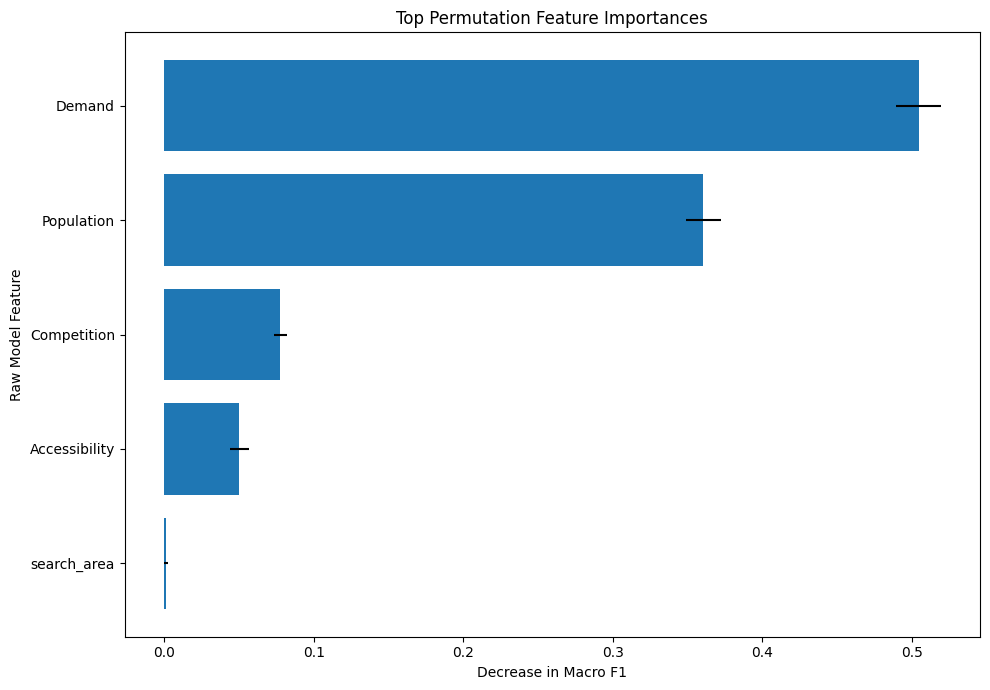

Feature importance saved to: C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results\feature_importance.csv


In [12]:
# ============================================================
# 12. PLOT AND SAVE THE TOP FEATURE IMPORTANCES
# ============================================================

if feature_importance_df is not None:
    TOP_FEATURE_COUNT = min(
        15,
        len(feature_importance_df)
    )

    top_feature_importance_df = (
        feature_importance_df
        .head(TOP_FEATURE_COUNT)
        .sort_values(
            by="Importance Mean",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_feature_importance_df["Feature"],
        top_feature_importance_df["Importance Mean"],
        xerr=top_feature_importance_df["Importance Std"]
    )

    plt.title("Top Permutation Feature Importances")
    plt.xlabel("Decrease in Macro F1")
    plt.ylabel("Raw Model Feature")
    plt.tight_layout()
    plt.show()

    FEATURE_IMPORTANCE_PATH = (
        OUTPUT_DIRECTORY
        / "feature_importance.csv"
    )

    feature_importance_df.to_csv(
        FEATURE_IMPORTANCE_PATH,
        index=False
    )

    print(
        "Feature importance saved to:",
        FEATURE_IMPORTANCE_PATH
    )


In [13]:
# ============================================================
# 13. DEFINE A SINGLE-LOCATION INPUT VALIDATION FUNCTION
# ============================================================
# The validation function checks:
#
# - Missing required features
# - Unexpected extra features
# - Invalid numerical values
# - Missing categorical values
#
# It then returns a one-row DataFrame in the exact feature order
# expected by the saved model.

def validate_location_features(location_features):
    """Validate one raw restaurant-location feature dictionary."""

    if not isinstance(location_features, dict):
        raise TypeError(
            "location_features must be provided as a dictionary."
        )

    missing_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in location_features
    ]

    if missing_features:
        raise ValueError(
            "Missing required features:\n"
            + "\n".join(
                f"- {feature}"
                for feature in missing_features
            )
        )

    unexpected_features = [
        feature
        for feature in location_features
        if feature not in MODEL_FEATURES
    ]

    if unexpected_features:
        print(
            "Warning: these extra features will be ignored:",
            unexpected_features
        )

    location_df = pd.DataFrame(
        [{
            feature: location_features[feature]
            for feature in MODEL_FEATURES
        }],
        columns=MODEL_FEATURES
    )

    for feature in NUMERIC_FEATURES:
        location_df[feature] = pd.to_numeric(
            location_df[feature],
            errors="coerce"
        )

        if location_df[feature].isna().all():
            raise ValueError(
                f"'{feature}' must contain a valid numeric value."
            )

        if float(location_df[feature].iloc[0]) < 0:
            raise ValueError(
                f"'{feature}' cannot be negative."
            )

    for feature in CATEGORICAL_FEATURES:
        value = location_df[feature].iloc[0]

        if pd.isna(value) or not str(value).strip():
            raise ValueError(
                f"'{feature}' must contain a non-empty value."
            )

        location_df[feature] = (
            location_df[feature]
            .astype("string")
            .str.strip()
        )

    return location_df


In [14]:
# ============================================================
# 14. DEFINE THE SINGLE-LOCATION PREDICTION FUNCTION
# ============================================================
# The loaded pipeline automatically applies the same:
#
# - Missing-value treatment
# - Numerical scaling
# - Categorical one-hot encoding
# - Tuned Logistic Regression classifier
#
# that were fitted during Phase 4.

def predict_location_feasibility(location_features):
    """Predict feasibility class and probabilities for one location."""

    location_df = validate_location_features(
        location_features
    )

    predicted_class = int(
        loaded_pipeline.predict(
            location_df
        )[0]
    )

    predicted_probabilities = (
        loaded_pipeline.predict_proba(
            location_df
        )[0]
    )

    # The class order must come from the fitted classifier.
    final_estimator = (
        loaded_pipeline.steps[-1][1]
        if hasattr(loaded_pipeline, "steps")
        else loaded_pipeline
    )

    classifier_classes = final_estimator.classes_

    probability_output = {
        LABEL_MAPPING.get(
            int(class_value),
            str(class_value)
        ): round(float(probability), 6)
        for class_value, probability
        in zip(
            classifier_classes,
            predicted_probabilities
        )
    }

    predicted_label = LABEL_MAPPING.get(
        predicted_class,
        str(predicted_class)
    )

    confidence = float(
        np.max(predicted_probabilities)
    )

    return {
        "predicted_class": predicted_class,
        "predicted_label": predicted_label,
        "confidence": round(confidence, 6),
        "probabilities": probability_output
    }


In [15]:
# ============================================================
# 15. PREPARE A SAMPLE LOCATION USING DATASET_FINAL_ENTROPY
# ============================================================
# The previous deployment example used individual POI-count
# features. The current model must instead receive exactly the
# features stored in MODEL_FEATURES.
#
# For the entropy-based dataset, these will normally include:
#
# - Demand
# - Accessibility
# - Competition
# - Population
# - search_area
#
# A realistic example is created from the median numerical values
# and the first available category in dataset_final_entropy.csv.
#
# You may later replace these values with dynamically calculated
# values from a user-selected map location.

selected_location_features = {}

if df is not None:
    for feature in MODEL_FEATURES:
        if feature in NUMERIC_FEATURES:
            selected_location_features[feature] = float(
                pd.to_numeric(
                    df[feature],
                    errors="coerce"
                ).median()
            )

        elif feature in CATEGORICAL_FEATURES:
            available_values = (
                df[feature]
                .dropna()
                .astype(str)
                .str.strip()
            )

            if available_values.empty:
                raise ValueError(
                    f"No valid category was found for '{feature}'."
                )

            selected_location_features[feature] = (
                available_values.iloc[0]
            )

else:
    # Manual fallback for the expected entropy-based features.
    # Replace these demonstration values with valid values from
    # your own feature-generation process.
    expected_entropy_example = {
        "Demand": 0.50,
        "Accessibility": 0.50,
        "Competition": 0.50,
        "Population": 0.50,
        "search_area": "Baneshwor"
    }

    selected_location_features = {
        feature: expected_entropy_example[feature]
        for feature in MODEL_FEATURES
        if feature in expected_entropy_example
    }

    missing_example_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in selected_location_features
    ]

    if missing_example_features:
        raise ValueError(
            "Create manual demonstration values for these features:\n"
            + "\n".join(
                f"- {feature}"
                for feature in missing_example_features
            )
        )

selected_location_df = validate_location_features(
    selected_location_features
)

print("Sample deployment input:")
display(selected_location_df)


Sample deployment input:


,Demand,Accessibility,Competition,Population,search_area
0,0.22615,0.39595,0.4916,0.352,Baneshwor


In [16]:
# ============================================================
# 16. CHECK SEARCH-AREA VALUES IN DATASET_FINAL_ENTROPY
# ============================================================
# OneHotEncoder(handle_unknown="ignore") allows a new search area
# to be processed, but known training categories are still useful
# for checking spelling and consistency.

if df is not None and "search_area" in df.columns:
    known_search_areas = sorted(
        df["search_area"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print("Known search areas:")
    for area in known_search_areas:
        print("-", area)


Known search areas:
- Baneshwor
- Bhaktapur durbar square
- Boudha stupa
- Durbar Marg
- Kirtipur
- Koteshwor
- New Road
- Patan durbar square
- Pulchowk


In [17]:
# ============================================================
# 17. PREDICT THE SELECTED LOCATION
# ============================================================

prediction_result = predict_location_feasibility(
    selected_location_features
)

print(
    "Predicted feasibility:",
    prediction_result["predicted_label"]
)

print(
    "Encoded class:",
    prediction_result["predicted_class"]
)

print(
    "Prediction confidence:",
    f"{prediction_result['confidence'] * 100:.2f}%"
)

print("\nPredicted class probabilities:")

for class_name, probability in (
    prediction_result["probabilities"].items()
):
    print(
        f"{class_name}: {probability:.4f} "
        f"({probability * 100:.2f}%)"
    )


Predicted feasibility: Moderate
Encoded class: 1
Prediction confidence: 100.00%

Predicted class probabilities:
Low: 0.0000 (0.00%)
Moderate: 1.0000 (100.00%)
High: 0.0000 (0.00%)


,Feasibility Class,Probability,Percentage
0,Moderate,1.0,100.0
1,Low,0.0,0.0
2,High,0.0,0.0


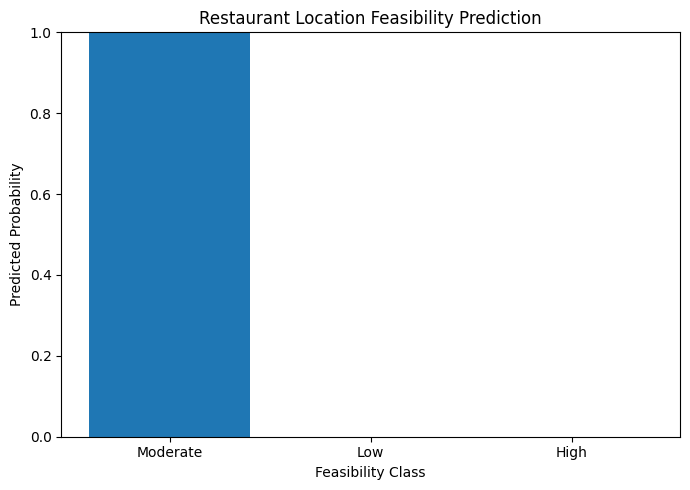

In [18]:
# ============================================================
# 18. DISPLAY AND PLOT THE PREDICTED PROBABILITIES
# ============================================================

probability_df = pd.DataFrame({
    "Feasibility Class": list(
        prediction_result["probabilities"].keys()
    ),
    "Probability": list(
        prediction_result["probabilities"].values()
    )
})

probability_df["Percentage"] = (
    probability_df["Probability"] * 100
).round(2)

probability_df = (
    probability_df
    .sort_values(
        by="Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(probability_df)

plt.figure(figsize=(7, 5))

plt.bar(
    probability_df["Feasibility Class"],
    probability_df["Probability"]
)

plt.title("Restaurant Location Feasibility Prediction")
plt.xlabel("Feasibility Class")
plt.ylabel("Predicted Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# 19. SAVE THE SAMPLE PREDICTION AS JSON
# ============================================================
# JSON is the standard response format that can later be returned
# by a FastAPI endpoint to the frontend application.

PREDICTION_OUTPUT_PATH = (
    OUTPUT_DIRECTORY
    / "sample_location_prediction.json"
)

prediction_payload = {
    "input_features": selected_location_features,
    "prediction": prediction_result
}

with open(
    PREDICTION_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as json_file:
    json.dump(
        prediction_payload,
        json_file,
        indent=4,
        ensure_ascii=False
    )

print(
    "Sample prediction saved to:",
    PREDICTION_OUTPUT_PATH
)


Sample prediction saved to: C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results\sample_location_prediction.json


In [20]:
# ============================================================
# 20. DEFINE A BATCH-PREDICTION FUNCTION
# ============================================================
# This function predicts multiple locations at once and is useful
# when evaluating many candidate points from a CSV file.

def predict_multiple_locations(locations):
    """Predict feasibility for a DataFrame or list of dictionaries."""

    if isinstance(locations, list):
        locations_df = pd.DataFrame(locations)
    elif isinstance(locations, pd.DataFrame):
        locations_df = locations.copy()
    else:
        raise TypeError(
            "locations must be a list of dictionaries or a DataFrame."
        )

    missing_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in locations_df.columns
    ]

    if missing_features:
        raise ValueError(
            "Batch input is missing these features:\n"
            + "\n".join(
                f"- {feature}"
                for feature in missing_features
            )
        )

    model_input_df = locations_df[
        MODEL_FEATURES
    ].copy()

    for feature in NUMERIC_FEATURES:
        model_input_df[feature] = pd.to_numeric(
            model_input_df[feature],
            errors="coerce"
        )

    predicted_classes = loaded_pipeline.predict(
        model_input_df
    )

    predicted_probabilities = loaded_pipeline.predict_proba(
        model_input_df
    )

    final_estimator = (
        loaded_pipeline.steps[-1][1]
        if hasattr(loaded_pipeline, "steps")
        else loaded_pipeline
    )

    classifier_classes = final_estimator.classes_

    result_df = locations_df.copy()

    result_df["predicted_class"] = (
        predicted_classes.astype(int)
    )

    result_df["predicted_label"] = [
        LABEL_MAPPING.get(int(value), str(value))
        for value in predicted_classes
    ]

    result_df["prediction_confidence"] = (
        predicted_probabilities.max(axis=1)
    )

    for class_index, class_value in enumerate(
        classifier_classes
    ):
        class_label = LABEL_MAPPING.get(
            int(class_value),
            str(class_value)
        )

        safe_label = (
            class_label.lower()
            .replace(" ", "_")
        )

        result_df[
            f"probability_{safe_label}"
        ] = predicted_probabilities[:, class_index]

    return result_df


In [21]:
# ============================================================
# 21. TEST BATCH PREDICTION
# ============================================================
# Two realistic demonstration locations are created from the
# numerical distributions in dataset_final_entropy.csv.
#
# Location 1 uses median values.
# Location 2 uses the 25th percentile for numerical features and,
# where possible, a different search area.

second_location_features = {}

if df is not None:
    for feature in MODEL_FEATURES:
        if feature in NUMERIC_FEATURES:
            second_location_features[feature] = float(
                pd.to_numeric(
                    df[feature],
                    errors="coerce"
                ).quantile(0.25)
            )

        elif feature in CATEGORICAL_FEATURES:
            category_values = (
                df[feature]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
                .tolist()
            )

            if not category_values:
                raise ValueError(
                    f"No valid category was found for '{feature}'."
                )

            second_location_features[feature] = (
                category_values[1]
                if len(category_values) > 1
                else category_values[0]
            )

else:
    second_location_features = (
        selected_location_features.copy()
    )

batch_prediction_df = predict_multiple_locations([
    selected_location_features,
    second_location_features
])

display(batch_prediction_df)


,Demand,Accessibility,Competition,Population,search_area,predicted_class,predicted_label,prediction_confidence,probability_low,probability_moderate,probability_high
0,0.226150,0.395950,0.491600,0.3520,Baneshwor,1,Moderate,1.000000,9.228234e-17,1.000000e+00,2.910438e-17
1,0.126075,0.333725,0.426575,0.2422,New Road,0,Low,0.999999,9.999993e-01,7.177655e-07,1.519189e-48


In [22]:
# ============================================================
# 22. SAVE BATCH PREDICTION RESULTS
# ============================================================

BATCH_PREDICTION_PATH = (
    OUTPUT_DIRECTORY
    / "batch_location_predictions.csv"
)

batch_prediction_df.to_csv(
    BATCH_PREDICTION_PATH,
    index=False
)

print(
    "Batch prediction results saved to:",
    BATCH_PREDICTION_PATH
)


Batch prediction results saved to: C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results\batch_location_predictions.csv


In [23]:
# ============================================================
# 23. VERIFY THE SAVED MODEL ON AN EXISTING DATASET ROW
# ============================================================
# This is a deployment smoke test. It confirms that the loaded
# model accepts raw dataset features and produces a valid result.

if X_importance_test is not None:
    sample_index = X_importance_test.index[0]

    sample_features = (
        X_importance_test
        .loc[sample_index]
        .to_dict()
    )

    sample_prediction = predict_location_feasibility(
        sample_features
    )

    actual_class = int(
        y_importance_test.loc[sample_index]
    )

    actual_label = LABEL_MAPPING.get(
        actual_class,
        str(actual_class)
    )

    print("Actual label:", actual_label)
    print(
        "Predicted label:",
        sample_prediction["predicted_label"]
    )
    print(
        "Prediction confidence:",
        f"{sample_prediction['confidence'] * 100:.2f}%"
    )
    print(
        "Probabilities:",
        sample_prediction["probabilities"]
    )


Actual label: Moderate
Predicted label: Moderate
Prediction confidence: 100.00%
Probabilities: {'Low': 0.0, 'Moderate': 1.0, 'High': 0.0}


In [24]:
# ============================================================
# 24. CREATE A DEPLOYMENT INFORMATION SUMMARY
# ============================================================
# This summary records the files and objects that the FastAPI
# backend will need in the next deployment step.

deployment_summary = {
    "project_root": str(PROJECT_ROOT),
    "model_path": str(MODEL_PATH),
    "dataset_path": str(DATA_PATH),
    "dataset_name": DATA_PATH.name,
    "model_name": loaded_metadata.get(
        "model_name",
        type(loaded_pipeline).__name__
    ),
    "number_of_features": len(MODEL_FEATURES),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "label_mapping": LABEL_MAPPING,
    "single_prediction_function": (
        "predict_location_feasibility"
    ),
    "batch_prediction_function": (
        "predict_multiple_locations"
    )
}

DEPLOYMENT_SUMMARY_PATH = (
    OUTPUT_DIRECTORY
    / "deployment_summary.json"
)

with open(
    DEPLOYMENT_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as json_file:
    json.dump(
        deployment_summary,
        json_file,
        indent=4,
        ensure_ascii=False
    )

print("Deployment preparation completed successfully.")
print(
    "Deployment summary saved to:",
    DEPLOYMENT_SUMMARY_PATH
)

display(
    pd.DataFrame([
        {
            "Model": deployment_summary["model_name"],
            "Model File Exists": MODEL_PATH.exists(),
            "Feature Count": len(MODEL_FEATURES),
            "Output Directory": str(OUTPUT_DIRECTORY)
        }
    ])
)


Deployment preparation completed successfully.
Deployment summary saved to: C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results\deployment_summary.json


,Model,Model File Exists,Feature Count,Output Directory
0,Logistic Regression,True,5,C:\Users\mausa\Desktop\grouping_approach\minor_prj\outputs\model_results
